##  개인정보 제공 동의의 계층적 조건: 객관적 경제 조건과 주관적 경제 인식의 비교

### 선행연구


**조사필요**

### 가설

본 연구는 개인정보 제공 동의(`GIVEPIFR_R`)에 영향을 미치는 경제적 요인을 **객관적 경제 조건**과 **주관적 경제 인식**으로 구분한다. 객관적 경제 조건은 월평균 가구소득의 로그값인 `log_INCOM0`으로 측정하고, 주관적 경제 인식은 `RANK`, `SATFIN_R`, `FINPROS_R`로 측정한다.

`GIVEPIFR_R`은 원척도 `GIVEPIFR`을 역코딩한 변수이므로, 값이 높을수록 할인이나 무료상품을 받기 위해 개인정보를 제공하는 데 더 동의한다는 의미이다.

**가설 설정은 선행연구 살펴보고 정할 수 있을거 같습니다**

In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm
from IPython.display import display
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
from statsmodels.stats.stattools import durbin_watson, jarque_bera
from patsy import dmatrices
from statsmodels.stats.outliers_influence import variance_inflation_factor

## 1. 데이터 불러오기

In [4]:
DATA_PATH = Path(r"/home/pck/data_jour/sda_Team Project_/adt_2025_drop_0509.csv")
df_raw = pd.read_csv(DATA_PATH)

print(df_raw.shape)
display(df_raw.head())

(1211, 455)


,YEAR,RESPID,YRRESPID,FINALWT,SEX,AGE,MARITAL,EMPLY,WHYNOE,EDUC,...,HHWHYNOE,HHDNO,HOMPOP,SEPAPOP,UNRELAT,REGION,URBAN,SAMPLEAB,INTDATM,INTDATD
0,2025.0,101.0,202500101.0,1.349140,1.0,44.0,1.0,1.0,-1.0,4.0,...,-1.0,11.0,3.0,0.0,0.0,1.0,1.0,1.0,4.0,6.0
1,2025.0,102.0,202500102.0,0.719461,2.0,62.0,1.0,2.0,3.0,3.0,...,-1.0,2.0,2.0,0.0,0.0,1.0,1.0,2.0,4.0,6.0
2,2025.0,103.0,202500103.0,0.572766,2.0,50.0,1.0,2.0,18.0,3.0,...,-1.0,4.0,3.0,0.0,0.0,1.0,1.0,2.0,4.0,7.0
3,2025.0,104.0,202500104.0,1.093403,1.0,62.0,1.0,1.0,-1.0,3.0,...,-1.0,10.0,2.0,0.0,0.0,1.0,1.0,2.0,5.0,25.0
4,2025.0,105.0,202500105.0,1.093403,1.0,74.0,1.0,2.0,19.0,2.0,...,19.0,12.0,2.0,0.0,0.0,1.0,1.0,2.0,4.0,8.0


## 2. 분석 변수 지정

분석에 사용할 핵심 변수를 지정한다. 


In [5]:
analysis_vars_raw = [
    "GIVEPIFR",
    "INCOM0", "RANK", "SATFIN", "FINPROS",
    "AGE", "SEX", "EDUC", "ABLITINF", "TECHHARM",
    "FINALWT",
]

missing = [v for v in analysis_vars_raw if v not in df_raw.columns]
if missing:
    raise ValueError(f"데이터에 없는 변수: {missing}")

display(df_raw[analysis_vars_raw].describe().T)


,count,mean,std,min,25%,50%,75%,max
GIVEPIFR,1211.0,3.507019,1.121057,-8.000000,3.000000,4.00000,4.000000,5.000000
INCOM0,1211.0,448.386457,407.973516,-8.000000,216.000000,400.00000,600.000000,9000.000000
RANK,1211.0,5.065235,1.498717,1.000000,4.000000,5.00000,6.000000,10.000000
SATFIN,1211.0,3.182494,0.886384,1.000000,3.000000,3.00000,4.000000,5.000000
FINPROS,1211.0,2.777870,0.988047,-8.000000,2.000000,3.00000,3.000000,5.000000
AGE,1211.0,52.611891,15.651251,18.000000,40.000000,54.00000,64.000000,93.000000
SEX,1211.0,1.610239,0.487897,1.000000,1.000000,2.00000,2.000000,2.000000
EDUC,1211.0,3.469860,1.483142,-8.000000,3.000000,3.00000,5.000000,8.000000
ABLITINF,1211.0,2.347647,1.545626,-8.000000,2.000000,2.00000,3.000000,5.000000
TECHHARM,1211.0,3.321222,0.988381,-8.000000,3.000000,3.00000,4.000000,5.000000


## 3. 데이터 전처리

- `-8`은 공통 결측 코드로 처리한다.
- `ABLITINF`의 `-1`은 비해당으로 보고 결측 처리한다.
- `GIVEPIFR`, `SATFIN`, `FINPROS`, `ABLITINF`, `TECHHARM`은 분석 방향에 맞게 역코딩한다.
- `INCOM0`는 `log_INCOM0 = log(INCOM0 + 1)`로 변환한다.


### `FINALWT`와 WLS 사용

`FINALWT`는 KGSS에서 제공하는 최종 표본가중치이다. 표본조사에서는 조사 표본이 모집단의 성별, 연령, 지역 등 분포와 완전히 일치하지 않을 수 있으므로, 각 응답자가 모집단에서 어느 정도의 대표성을 갖는지를 보정하기 위해 가중치를 사용한다. 
> kgss 공식 홈페이지 설명: '모든 연도에 적용할 가중치 변수는 가구에서 적격한 성인가구원 추출할 확률과 성별/연령/지역/도시(농촌)을 고려하여 만든 FINALWT 입니다.' (링크: https://kgss.skku.edu/kgss/faq.do#a )

본 분석에서는 `FINALWT`를 가중치로 사용한 WLS(Weighted Least Squares)를 적용한다. WLS는 모든 응답자를 동일한 비중으로 취급하는 OLS와 달리, 가중치가 큰 응답자는 더 큰 비중으로, 가중치가 작은 응답자는 더 작은 비중으로 반영한다. 따라서 본 연구의 WLS 결과는 KGSS의 표본가중치를 반영한 회귀분석 결과로 해석한다.
> 즉, 2025년 표본 자체가 모집단을 완벽히 반영하는 표본이 아닐 수 있기 때문에, 표본의 모집단 대표성을 보정하는 측면에서 사용한다. 


In [6]:
df = df_raw[analysis_vars_raw].copy()

# FINALWT는 이후 WLS 회귀분석에서 표본가중치로 사용한다.

# 공통 결측 코드 처리
for col in analysis_vars_raw:
    df[col] = df[col].replace(-8, np.nan)

# ABLITINF의 -1은 비해당으로 보고 결측 처리
df["ABLITINF"] = df["ABLITINF"].replace(-1, np.nan)

# 종속변수 개인정보 제공 태도 역코딩: 원척도 1=매우 동의, 5=매우 반대
# 분석척도는 1=매우 반대, 5=매우 동의
df["GIVEPIFR_R"] = np.where(df["GIVEPIFR"].isin([1, 2, 3, 4, 5]), 6 - df["GIVEPIFR"], np.nan)

# 독립변수/통제변수 역코딩
# SATFIN_R: 1=매우 불만족, 5=매우 만족
# FINPROS_R: 1=상당히 나빠질 것, 5=상당히 좋아질 것
# ABLITINF_R: 1=매우 낮음, 5=매우 높음
for v in ["SATFIN", "FINPROS", "ABLITINF"]:
    df[f"{v}_R"] = np.where(df[v].isin([1, 2, 3, 4, 5]), 6 - df[v], np.nan)

# TECHHARM_R: 값이 높을수록 기술위험 인식이 높도록 역코딩
df["TECHHARM_R"] = np.where(df["TECHHARM"].isin([1, 2, 3, 4, 5]), 6 - df["TECHHARM"], np.nan)

# INCOM0 변수 로그 변환
df["log_INCOM0"] = np.log1p(df["INCOM0"].where(df["INCOM0"] >= 0, np.nan))

# EDUC -> EDUC_GROUP
# 고졸 이하: 0=무학, 1=초등학교, 2=중학교, 3=고등학교, 8=서당한학 / 2년제 대학: 4=전문대학 / 4년제 대학: 5=대학교 / 대학원 이상: 6=대학원 석사, 7=대학원 박사
educ_categories = ["고졸 이하", "2년제 대학", "4년제 대학", "대학원 이상"]
df["EDUC_GROUP"] = pd.Series(pd.NA, index=df.index, dtype="object")
df.loc[df["EDUC"].isin([0, 1, 2, 3, 8]), "EDUC_GROUP"] = "고졸 이하"
df.loc[df["EDUC"].eq(4), "EDUC_GROUP"] = "2년제 대학"
df.loc[df["EDUC"].eq(5), "EDUC_GROUP"] = "4년제 대학"
df.loc[df["EDUC"].isin([6, 7]), "EDUC_GROUP"] = "대학원 이상"
df["EDUC_GROUP"] = pd.Categorical(df["EDUC_GROUP"], categories=educ_categories, ordered=True)


display(df.head())
display(df[["GIVEPIFR", "GIVEPIFR_R", "SATFIN_R", "FINPROS_R", "ABLITINF_R", "log_INCOM0", "EDUC", "EDUC_GROUP", "TECHHARM_R"]].head())
display(df.isna().sum())

,GIVEPIFR,INCOM0,RANK,SATFIN,FINPROS,AGE,SEX,EDUC,ABLITINF,TECHHARM,FINALWT,GIVEPIFR_R,SATFIN_R,FINPROS_R,ABLITINF_R,TECHHARM_R,log_INCOM0,EDUC_GROUP
0,3.0,600.0,4.0,4.0,4.0,44.0,1.0,4.0,2.0,2.0,1.349140,3.0,2.0,2.0,4.0,4.0,6.398595,2년제 대학
1,2.0,280.0,4.0,4.0,4.0,62.0,2.0,3.0,2.0,4.0,0.719461,4.0,2.0,2.0,4.0,2.0,5.638355,고졸 이하
2,3.0,250.0,5.0,3.0,2.0,50.0,2.0,3.0,2.0,2.0,0.572766,3.0,3.0,4.0,4.0,4.0,5.525453,고졸 이하
3,2.0,NaN,2.0,4.0,4.0,62.0,1.0,3.0,2.0,3.0,1.093403,4.0,2.0,2.0,4.0,3.0,NaN,고졸 이하
4,4.0,320.0,3.0,5.0,4.0,74.0,1.0,2.0,3.0,3.0,1.093403,2.0,1.0,2.0,3.0,3.0,5.771441,고졸 이하


,GIVEPIFR,GIVEPIFR_R,SATFIN_R,FINPROS_R,ABLITINF_R,log_INCOM0,EDUC,EDUC_GROUP,TECHHARM_R
0,3.0,3.0,2.0,2.0,4.0,6.398595,4.0,2년제 대학,4.0
1,2.0,4.0,2.0,2.0,4.0,5.638355,3.0,고졸 이하,2.0
2,3.0,3.0,3.0,4.0,4.0,5.525453,3.0,고졸 이하,4.0
3,2.0,4.0,2.0,2.0,4.0,NaN,3.0,고졸 이하,3.0
4,4.0,2.0,1.0,2.0,3.0,5.771441,2.0,고졸 이하,3.0


GIVEPIFR       1
INCOM0        60
RANK           0
SATFIN         0
FINPROS        4
AGE            0
SEX            0
EDUC           1
ABLITINF      88
TECHHARM       1
FINALWT        0
GIVEPIFR_R     1
SATFIN_R       0
FINPROS_R      4
ABLITINF_R    88
TECHHARM_R     1
log_INCOM0    60
EDUC_GROUP     1
dtype: int64

In [7]:
# NaN 값 제거

analysis_vars = [
    "GIVEPIFR_R",
    "log_INCOM0", "RANK", "SATFIN_R", "FINPROS_R",
    "AGE", "SEX", "EDUC_GROUP", "ABLITINF_R", "TECHHARM_R",
    "FINALWT",
]

adt = df.dropna(subset=analysis_vars).copy().reset_index(drop=True)

print(f"결측 제거 전 df 행 수: {len(df)}")
print(f"결측 제거 후 adt 행 수: {len(adt)}")
print(f"제거된 행 수: {len(df) - len(adt)}")

display(adt.head())
display(adt[analysis_vars].isna().sum())

결측 제거 전 df 행 수: 1211
결측 제거 후 adt 행 수: 1067
제거된 행 수: 144


,GIVEPIFR,INCOM0,RANK,SATFIN,FINPROS,AGE,SEX,EDUC,ABLITINF,TECHHARM,FINALWT,GIVEPIFR_R,SATFIN_R,FINPROS_R,ABLITINF_R,TECHHARM_R,log_INCOM0,EDUC_GROUP
0,3.0,600.0,4.0,4.0,4.0,44.0,1.0,4.0,2.0,2.0,1.349140,3.0,2.0,2.0,4.0,4.0,6.398595,2년제 대학
1,2.0,280.0,4.0,4.0,4.0,62.0,2.0,3.0,2.0,4.0,0.719461,4.0,2.0,2.0,4.0,2.0,5.638355,고졸 이하
2,3.0,250.0,5.0,3.0,2.0,50.0,2.0,3.0,2.0,2.0,0.572766,3.0,3.0,4.0,4.0,4.0,5.525453,고졸 이하
3,4.0,320.0,3.0,5.0,4.0,74.0,1.0,2.0,3.0,3.0,1.093403,2.0,1.0,2.0,3.0,3.0,5.771441,고졸 이하
4,2.0,300.0,4.0,4.0,4.0,53.0,2.0,3.0,3.0,4.0,0.572766,4.0,2.0,2.0,3.0,2.0,5.707110,고졸 이하


GIVEPIFR_R    0
log_INCOM0    0
RANK          0
SATFIN_R      0
FINPROS_R     0
AGE           0
SEX           0
EDUC_GROUP    0
ABLITINF_R    0
TECHHARM_R    0
FINALWT       0
dtype: int64

## 4. 기술통계와 상관관계

,count,mean,std,min,25%,50%,75%,max
GIVEPIFR,1067.0,3.492971,1.067469,1.0,3.000000,4.000000,4.00000,5.000000
GIVEPIFR_R,1067.0,2.507029,1.067469,1.0,2.000000,2.000000,3.00000,5.000000
INCOM0,1067.0,499.305530,407.348520,0.0,280.000000,420.000000,650.00000,9000.000000
log_INCOM0,1067.0,5.987214,0.739418,0.0,5.638355,6.042633,6.47851,9.105091
RANK,1067.0,5.112465,1.476681,1.0,4.000000,5.000000,6.00000,10.000000
SATFIN,1067.0,3.173383,0.871115,1.0,3.000000,3.000000,4.00000,5.000000
SATFIN_R,1067.0,2.826617,0.871115,1.0,2.000000,3.000000,3.00000,5.000000
FINPROS,1067.0,2.790066,0.750844,1.0,2.000000,3.000000,3.00000,5.000000
FINPROS_R,1067.0,3.209934,0.750844,1.0,3.000000,3.000000,4.00000,5.000000
AGE,1067.0,51.167760,14.308874,19.0,40.000000,53.000000,62.00000,93.000000


,count
EDUC_GROUP,
고졸 이하,549
2년제 대학,167
4년제 대학,318
대학원 이상,33


,percent
EDUC_GROUP,
고졸 이하,51.45
2년제 대학,15.65
4년제 대학,29.80
대학원 이상,3.09


,GIVEPIFR_R,INCOM0,log_INCOM0,RANK,SATFIN_R,FINPROS_R,ABLITINF_R,TECHHARM_R
GIVEPIFR_R,1.000000,0.032442,0.036540,0.041156,-0.067792,0.008691,0.132219,0.088972
INCOM0,0.032442,1.000000,0.734905,0.316339,0.227830,0.157795,0.183998,0.057529
log_INCOM0,0.036540,0.734905,1.000000,0.396417,0.282593,0.189499,0.254500,0.102671
RANK,0.041156,0.316339,0.396417,1.000000,0.460020,0.188511,0.183974,0.049906
SATFIN_R,-0.067792,0.227830,0.282593,0.460020,1.000000,0.245020,0.100658,0.062899
FINPROS_R,0.008691,0.157795,0.189499,0.188511,0.245020,1.000000,0.295122,-0.009180
ABLITINF_R,0.132219,0.183998,0.254500,0.183974,0.100658,0.295122,1.000000,0.039500
TECHHARM_R,0.088972,0.057529,0.102671,0.049906,0.062899,-0.009180,0.039500,1.000000


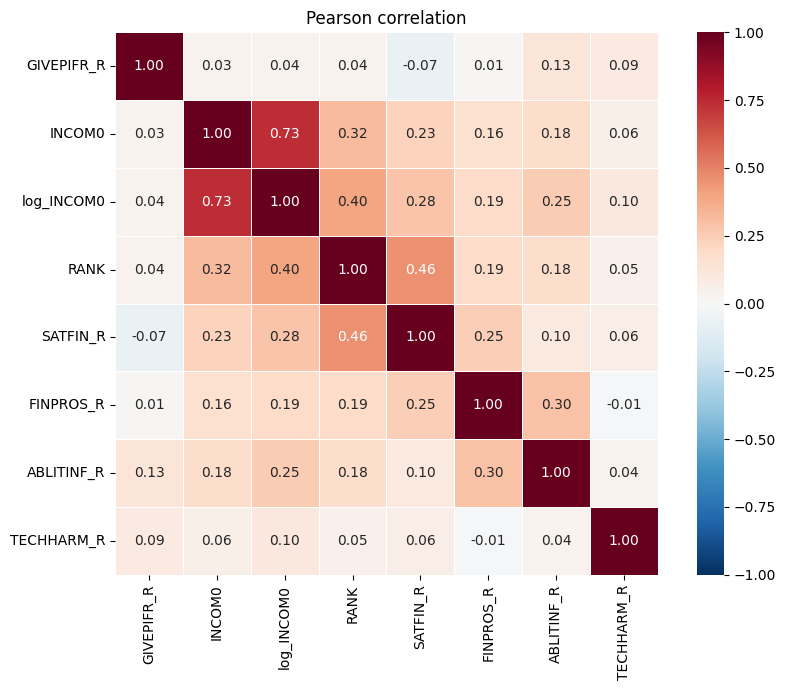

In [8]:
summary_vars = [
    "GIVEPIFR", "GIVEPIFR_R",
    "INCOM0", "log_INCOM0", "RANK",
    "SATFIN", "SATFIN_R", "FINPROS", "FINPROS_R",
    "AGE", "SEX", "EDUC", "ABLITINF", "ABLITINF_R", "TECHHARM", "TECHHARM_R",
]
display(adt[summary_vars].describe().T)

# 범주화한 학력 변수 분포
display(adt["EDUC_GROUP"].value_counts().reindex(educ_categories).to_frame("count"))
display((adt["EDUC_GROUP"].value_counts(normalize=True).reindex(educ_categories) * 100).round(2).to_frame("percent"))

corr_vars = ["GIVEPIFR_R", "INCOM0", "log_INCOM0", "RANK", "SATFIN_R", "FINPROS_R", "ABLITINF_R", "TECHHARM_R"]
corr_matrix = adt[corr_vars].corr(method="pearson")
display(corr_matrix)

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
)
plt.title("Pearson correlation")
plt.tight_layout()
plt.show()

## 5. 회귀분석 기본 가정 점검

회귀분석 이전에 분석 6의 전체 모형을 기준으로 회귀분석의 기본 가정을 점검한다. 

1. 선형성: 예측값과 잔차의 관계가 특정한 곡선 패턴을 보이지 않는지 확인한다.
2. 독립성: Durbin-Watson 통계량을 참고해 잔차의 자기상관 가능성을 확인한다. (본 연구는 시계열 자료가 아닌 횡단면 설문자료를 사용하므로 이를 자기상관의 직접적 증거로 해석하기보다는 참고 지표로 활용)
3. 등분산성: Breusch-Pagan 검정과 White 검정을 사용한다.
4. 정규성: Q-Q plot과 Jarque-Bera 검정을 사용한다.

추가로, 독립변수들 사이의 다중공선성을 확인하기 위해 VIF도 같은 파트에서 점검한다.

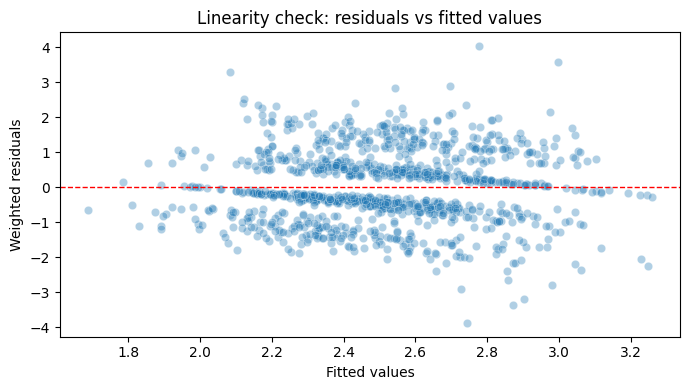

,model,durbin_watson
0,ASSUMPTION_WLS_ANALYSIS6_FULL,1.530189


,model,nobs,bp_lm_stat,bp_lm_pvalue,bp_f_stat,bp_f_pvalue,white_lm_stat,white_lm_pvalue,white_f_stat,white_f_pvalue,bp_heteroskedasticity_5pct,white_heteroskedasticity_5pct
0,ASSUMPTION_WLS_ANALYSIS6_FULL,1067,67.653208,3.403982e-10,6.492799,1.588322e-10,152.722266,4.291660e-08,2.376761,7.090448e-09,True,True


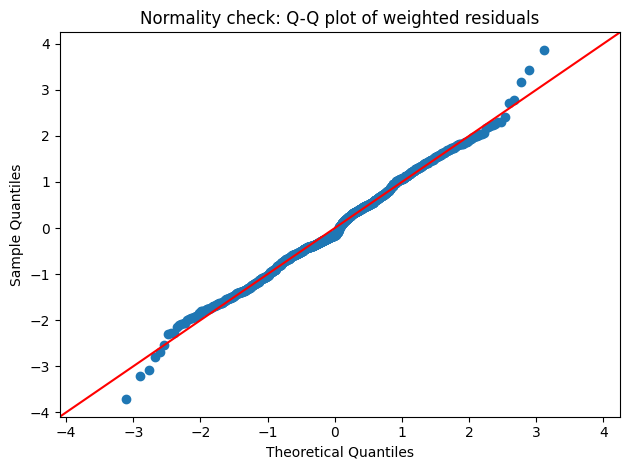

,model,jarque_bera_stat,jarque_bera_pvalue,skew,kurtosis,normality_rejected_5pct
0,ASSUMPTION_WLS_ANALYSIS6_FULL,1.301356,0.521692,0.085244,3.014335,False


,model,term,vif
0,VIF_ANALYSIS6_FULL,AGE,1.788888
1,VIF_ANALYSIS6_FULL,ABLITINF_R,1.654705
2,VIF_ANALYSIS6_FULL,C(EDUC_GROUP)[T.4년제 대학],1.574321
3,VIF_ANALYSIS6_FULL,RANK,1.441444
4,VIF_ANALYSIS6_FULL,SATFIN_R,1.354512
5,VIF_ANALYSIS6_FULL,log_INCOM0,1.308262
6,VIF_ANALYSIS6_FULL,C(EDUC_GROUP)[T.2년제 대학],1.267983
7,VIF_ANALYSIS6_FULL,FINPROS_R,1.225867
8,VIF_ANALYSIS6_FULL,C(EDUC_GROUP)[T.대학원 이상],1.176419
9,VIF_ANALYSIS6_FULL,C(SEX)[T.2.0],1.038111


In [ ]:
assumption_formula_main = (
    "GIVEPIFR_R ~ log_INCOM0 + RANK + SATFIN_R + FINPROS_R + AGE "
    "+ C(SEX) + C(EDUC_GROUP) + ABLITINF_R + TECHHARM_R"
)

# 분석 6과 같은 전체 WLS 모형으로 가정 점검
assumption_wls = smf.wls(
    formula=assumption_formula_main,
    data=adt,
    weights=adt["FINALWT"]
).fit()

# 1. 선형성: 예측값과 WLS 가중 잔차의 관계 확인
# 잔차들이 특정 패턴을 보이지 않고 무작위로 고르게 분포해 있다. -> 선형성 가정 충족
plt.figure(figsize=(7, 4))
sns.scatterplot(x=assumption_wls.fittedvalues, y=assumption_wls.wresid, alpha=0.35)
plt.axhline(0, color="red", linestyle="--", linewidth=1)
plt.xlabel("Fitted values")
plt.ylabel("Weighted residuals")
plt.title("Linearity check: residuals vs fitted values")
plt.tight_layout()
plt.show()

# 2. 독립성: Durbin-Watson 통계량 확인
# 1.530189
independence_results = pd.DataFrame([{
    "model": "ASSUMPTION_WLS_ANALYSIS6_FULL",
    "durbin_watson": durbin_watson(assumption_wls.wresid),
}])
display(independence_results)

# 3. 등분산성: Breusch-Pagan 검정과 White 검정
# wresid는 statsmodels가 WLS 계산에 사용한 가중 잔차다.
# BP/White 검정 함수는 상수항이 있는 설명변수 행렬을 요구하므로 exog는 원 설계행렬을 사용한다.
bp = het_breuschpagan(assumption_wls.wresid, assumption_wls.model.exog)
white = het_white(assumption_wls.wresid, assumption_wls.model.exog)

heteroskedasticity_results = pd.DataFrame([{
    "model": "ASSUMPTION_WLS_ANALYSIS6_FULL",
    "nobs": int(assumption_wls.nobs),
    "bp_lm_stat": bp[0],
    "bp_lm_pvalue": bp[1],
    "bp_f_stat": bp[2],
    "bp_f_pvalue": bp[3],
    "white_lm_stat": white[0],
    "white_lm_pvalue": white[1],
    "white_f_stat": white[2],
    "white_f_pvalue": white[3],
    "bp_heteroskedasticity_5pct": bp[1] < 0.05,
    "white_heteroskedasticity_5pct": white[1] < 0.05,
}])
display(heteroskedasticity_results)

# 4. 정규성: Q-Q plot과 Jarque-Bera 검정
sm.qqplot(assumption_wls.wresid, line="45", fit=True)
plt.title("Normality check: Q-Q plot of weighted residuals")
plt.tight_layout()
plt.show()

jb_stat, jb_pvalue, skew, kurtosis = jarque_bera(assumption_wls.wresid)
normality_results = pd.DataFrame([{
    "model": "ASSUMPTION_WLS_ANALYSIS6_FULL",
    "jarque_bera_stat": jb_stat,
    "jarque_bera_pvalue": jb_pvalue,
    "skew": skew,
    "kurtosis": kurtosis,
    "normality_rejected_5pct": jb_pvalue < 0.05,
}])
display(normality_results)

# 추가 점검: 다중공선성 VIF
_, X = dmatrices(assumption_formula_main, data=adt, return_type="dataframe")
vif_rows = []
for i, col in enumerate(X.columns):
    if col == "Intercept":
        continue
    vif_rows.append({
        "model": "VIF_ANALYSIS6_FULL",
        "term": col,
        "vif": variance_inflation_factor(X.values, i),
    })

vif_results = pd.DataFrame(vif_rows).sort_values("vif", ascending=False).reset_index(drop=True)
display(vif_results)


**기본가정 점검** 

  1. 선형성

  예측값과 WLS 가중 잔차의 산점도를 확인한 결과, 잔차가 0을 중심으로 특별한 곡선 패턴 없이 퍼져 있다면 선형성 가정은 대체로 충족된다고 볼 수 있다. 

  즉, 분석 6의 전체 모형에서 log_INCOM0, RANK, SATFIN_R, FINPROS_R와 통제변수들이 GIVEPIFR_R과 완전히 비선형적인 관계를 보인다고 판단할 근거는 크지 않다. 

  정리하면:

  > 잔차-예측값 그래프에서 뚜렷한 곡선 패턴이 나타나지 않아 선형성 가정을 충족하는 것으로 판단하였다. 

  2. 독립성

  Durbin-Watson 값은 약 1.53이다. 

  Durbin-Watson은 보통 2에 가까울수록 잔차 간 자기상관이 없다고 본다. 1.53은 2보다 낮기 때문에 약한 양의 자기상관 가능성을 시사할 수 있다. 

  다만 우리 자료는 시계열 자료가 아니라 KGSS 2025년 횡단면 설문자료이다. 따라서 Durbin-Watson을 시계열 분석처럼 강하게 해석할 필요는 없다. 

  정리하면:

  > Durbin-Watson 값은 2보다 낮지만, 본 연구는 횡단면 설문자료를 사용하므로 자기상관의 직접적 증거라기보다는 참고 지표로 해석하는 것이 적절하다.

  3. *등분산성*

  Breusch-Pagan 검정과 White 검정 결과에서 p값이 매우 작게 나왔다. 

  이 경우 귀무가설인 “오차의 분산이 일정하다”를 기각한다. 즉, 이분산성이 존재한다고 볼 수 있다. 

  정리하면:
  
  > BP 검정과 White 검정 결과, 등분산성 가정은 충족되지 않는 것으로 나타났다. 따라서 회귀계수의 방향 자체보다 표준오차, p값, 신뢰구간 해석에 주의가 필요하다.  
  > wls 가중치를 적용한 후에도 여전히 이분산성이 남아있다. 
  > 이분산성 교정을 위해 가중최소자승법(WLS)을 적용한 후 가중 잔차에 대해 Breusch-Pagan 및 White 검정을 수행한 결과, $p$-값이 0.05 미만으로 나타나 통계적으로는 잔여 이분산성이 존재하는 것으로 확인되었다. 그러나 앞선 잔차 산점도에서 확인한 바와 같이 가중 잔차의 변동 폭이 전 범위에 걸쳐 시각적으로 일정하게 유지되고 있으며, WLS 적용을 통해 OLS 대비 이분산성의 왜곡 효과를 상당 부분 완화하였기에 본 모형의 추정치를 신뢰할 수 있다고 판단하였다.


  4. 정규성

  Jarque-Bera 검정의 p값은 약 0.522로 확인되었다.

  p값이 0.05보다 크므로, 잔차가 정규분포를 따른다는 귀무가설을 기각하지 않는다. 즉, 정규성 가정은 크게 위배되지 않는다고 볼 수 있다.

  Q-Q plot에서도 점들이 대체로 기준선 주변에 놓여 있다면 정규성 가정은 무난하다고 해석할 수 있다.

  정리하면:

  > Jarque-Bera 검정 결과 정규성 가정은 기각되지 않았으며, 잔차의 정규성에는 큰 문제가 없어 보인다.

정리

회귀분석의 기본 가정을 점검한 결과, 잔차-예측값 그래프에서 뚜렷한 비선형 패턴은 확인되지 않았고, Jarque-Bera 검정에서도 잔차의 정규성은 기각되지 않았다. Durbin-Watson 통계량은 약 1.53으로 나타났으나, 본 연구는 횡단면 설문자료를 사용하므로 이를 자기상관의 직접적 증거로 해석하기보다는 참고 지표로 활용하였다. 한편 Breusch-Pagan 및 White 검정 결과 이분산성이 확인되어, 회귀계수의 통계적 유의성 해석에는 주의가 필요하다.

질문:  wls 를 사용해도 여전히, 등분산성 가정이 충족되지 않는다. 이 경우 어떻게 해석할 수 있을까? 

## 6. WLS 회귀분석: 분석 모형 구성

종속변수: `GIVEPIFR_R` (값이 높을수록 할인이나 무료상품을 받기 위해 개인정보를 제공하는 데 더 동의한다는 의미)

통제변수는 다음과 같다.

| 변수 | 분석상 역할 | 해석 |
|---|---|---|
| `AGE` | 통제변수 | 응답자 연령(min=18, max=93) |
| `SEX` | 통제변수 | 응답자 성별. 회귀식에서는 `C(SEX)`로 범주형 처리 |
| `EDUC_GROUP` | 통제변수 | 응답자 학력을 고졸 이하, 2년제 대학, 4년제 대학, 대학원 이상으로 재범주화한 변수. 회귀식에서는 `C(EDUC_GROUP)`으로 범주형 처리 |
| `ABLITINF_R` | 통제변수 | 인터넷 정보판별능력 역코딩 변수. 값이 높을수록 정보판별능력이 높음 |
| `TECHHARM_R` | 통제변수 | 기술위험 인식 역코딩 변수. 값이 높을수록 기술위험 인식이 높음 |

분석별 독립변수 구성은 다음과 같다.

| 분석 | 종속변수 | 독립변수 | 통제변수 |
|---|---|---|---|
| 분석 1 | `GIVEPIFR_R` | `log_INCOM0` | `AGE`, `SEX`, `EDUC_GROUP`, `ABLITINF_R`, `TECHHARM_R` |
| 분석 2 | `GIVEPIFR_R` | `RANK` | `AGE`, `SEX`, `EDUC_GROUP`, `ABLITINF_R`, `TECHHARM_R` |
| 분석 3 | `GIVEPIFR_R` | `SATFIN_R` | `AGE`, `SEX`, `EDUC_GROUP`, `ABLITINF_R`, `TECHHARM_R` |
| 분석 4 | `GIVEPIFR_R` | `FINPROS_R` | `AGE`, `SEX`, `EDUC_GROUP`, `ABLITINF_R`, `TECHHARM_R` |
| 분석 5 | `GIVEPIFR_R` | `RANK`, `SATFIN_R`, `FINPROS_R` | `AGE`, `SEX`, `EDUC_GROUP`, `ABLITINF_R`, `TECHHARM_R` |
| 분석 6 | `GIVEPIFR_R` | `log_INCOM0`, `RANK`, `SATFIN_R`, `FINPROS_R` | `AGE`, `SEX`, `EDUC_GROUP`, `ABLITINF_R`, `TECHHARM_R` |


In [ ]:
# 분석 1: log_INCOM0 + 통제변수
formula_analysis1 = (
    "GIVEPIFR_R ~ log_INCOM0 + AGE + C(SEX) + C(EDUC_GROUP) + ABLITINF_R + TECHHARM_R"
)
analysis1_model = smf.wls(
    formula=formula_analysis1,
    data=adt,
    weights=adt["FINALWT"]
).fit()

# 분석 2: RANK + 통제변수
formula_analysis2 = (
    "GIVEPIFR_R ~ RANK + AGE + C(SEX) + C(EDUC_GROUP) + ABLITINF_R + TECHHARM_R"
)
analysis2_model = smf.wls(
    formula=formula_analysis2,
    data=adt,
    weights=adt["FINALWT"]
).fit()

# 분석 3: SATFIN_R + 통제변수
formula_analysis3 = (
    "GIVEPIFR_R ~ SATFIN_R + AGE + C(SEX) + C(EDUC_GROUP) + ABLITINF_R + TECHHARM_R"
)
analysis3_model = smf.wls(
    formula=formula_analysis3,
    data=adt,
    weights=adt["FINALWT"]
).fit()

# 분석 4: FINPROS_R + 통제변수
formula_analysis4 = (
    "GIVEPIFR_R ~ FINPROS_R + AGE + C(SEX) + C(EDUC_GROUP) + ABLITINF_R + TECHHARM_R"
)
analysis4_model = smf.wls(
    formula=formula_analysis4,
    data=adt,
    weights=adt["FINALWT"]
).fit()

# 분석 5: RANK, SATFIN_R, FINPROS_R + 통제변수
formula_analysis5 = (
    "GIVEPIFR_R ~ RANK + SATFIN_R + FINPROS_R + AGE "
    "+ C(SEX) + C(EDUC_GROUP) + ABLITINF_R + TECHHARM_R"
)
analysis5_model = smf.wls(
    formula=formula_analysis5,
    data=adt,
    weights=adt["FINALWT"]
).fit()

# 분석 6: log_INCOM0, RANK, SATFIN_R, FINPROS_R + 통제변수
formula_analysis6 = (
    "GIVEPIFR_R ~ log_INCOM0 + RANK + SATFIN_R + FINPROS_R + AGE "
    "+ C(SEX) + C(EDUC_GROUP) + ABLITINF_R + TECHHARM_R"
)
analysis6_model = smf.wls(
    formula=formula_analysis6,
    data=adt,
    weights=adt["FINALWT"]
).fit()

models = {
    "ANALYSIS_1_WLS_GIVEPIFR_R_logINCOM0": analysis1_model,
    "ANALYSIS_2_WLS_GIVEPIFR_R_RANK": analysis2_model,
    "ANALYSIS_3_WLS_GIVEPIFR_R_SATFIN_R": analysis3_model,
    "ANALYSIS_4_WLS_GIVEPIFR_R_FINPROS_R": analysis4_model,
    "ANALYSIS_5_WLS_GIVEPIFR_R_SUBJECTIVE": analysis5_model,
    "ANALYSIS_6_WLS_GIVEPIFR_R_FULL": analysis6_model,
}

# 핵심 독립변수 중심 요약표
key_terms_by_model = {
    "ANALYSIS_1_WLS_GIVEPIFR_R_logINCOM0": ["log_INCOM0"],
    "ANALYSIS_2_WLS_GIVEPIFR_R_RANK": ["RANK"],
    "ANALYSIS_3_WLS_GIVEPIFR_R_SATFIN_R": ["SATFIN_R"],
    "ANALYSIS_4_WLS_GIVEPIFR_R_FINPROS_R": ["FINPROS_R"],
    "ANALYSIS_5_WLS_GIVEPIFR_R_SUBJECTIVE": ["RANK", "SATFIN_R", "FINPROS_R"],
    "ANALYSIS_6_WLS_GIVEPIFR_R_FULL": ["log_INCOM0", "RANK", "SATFIN_R", "FINPROS_R"],
}

result_rows = []
for model_name, model in models.items():
    conf_int = model.conf_int()
    for term in key_terms_by_model[model_name]:
        result_rows.append({
            "model": model_name,
            "term": term,
            "coef": model.params[term],
            "std_err": model.bse[term],
            "p_value": model.pvalues[term],
            "ci_low": conf_int.loc[term, 0],
            "ci_high": conf_int.loc[term, 1],
            "nobs": int(model.nobs),
            "r_squared": model.rsquared,
            "adj_r_squared": model.rsquared_adj,
        })

wls_key_results = pd.DataFrame(result_rows)
display(wls_key_results)

# 전체 회귀표
for model_name, model in models.items():
    print("=" * 100)
    print(model_name)
    print(model.summary())


## 7. 분석결과

*아래 해석은 모든 분석에서 `AGE`, `SEX`, `EDUC_GROUP`, `ABLITINF_R`, `TECHHARM_R`를 통제한 WLS 결과를 기준으로 한다.*


> **분석 1:** `log_INCOM0`의 계수는 -0.029이고 p값은 0.564로 통계적으로 유의하지 않다. 즉, 객관적 경제 조건인 월평균 가구소득은 개인정보 제공 동의와 뚜렷한 관련을 보이지 않는다.

> **분석 2:** `RANK`의 계수는 0.023이고 p값은 0.323으로 통계적으로 유의하지 않다. 주관적 계층의식을 단독으로 투입했을 때는 개인정보 제공 동의와 유의한 관련이 확인되지 않는다.

> **분석 3:** `SATFIN_R`의 계수는 -0.077이고 p값은 0.047로 5% 수준에서 유의하다. `SATFIN_R`은 값이 높을수록 가계상태 만족도가 높다는 뜻이므로, 가계상태 만족도가 높을수록 개인정보 제공 동의는 낮아지는 방향이다. 반대로 가계상태 만족도가 낮을수록 개인정보 제공 동의가 높다고 해석할 수 있다.

> **분석 4:** `FINPROS_R`의 계수는 -0.050이고 p값은 0.286으로 통계적으로 유의하지 않다. 가계경제 전망은 단독 모형에서 개인정보 제공 동의와 뚜렷한 관련을 보이지 않는다.

> **분석 5:** 주관적 경제 인식 변수인 `RANK`, `SATFIN_R`, `FINPROS_R`를 함께 투입한 결과, `RANK`는 양의 방향으로 유의하고(coef=0.055, p=0.037), `SATFIN_R`은 음의 방향으로 유의하다(coef=-0.108, p=0.012). `FINPROS_R`는 유의하지 않다(p=0.433). 즉, 주관적 계층의식이 높을수록 개인정보 제공 동의가 높고, 가계상태 만족도가 낮을수록 개인정보 제공 동의가 높은 경향이 나타난다.

> **분석 6:** 객관적 경제 조건(`log_INCOM0`)과 주관적 경제 인식(`RANK`, `SATFIN_R`, `FINPROS_R`)을 함께 투입한 결과, `log_INCOM0`는 유의하지 않다(p=0.511). 반면 `RANK`는 양의 방향으로 유의하고(coef=0.060, p=0.029), `SATFIN_R`은 음의 방향으로 유의하다(coef=-0.105, p=0.016). `FINPROS_R`는 유의하지 않다(p=0.442). 따라서 객관적 소득보다는 주관적 계층의식과 현재 가계상태 만족도가 개인정보 제공 동의와 더 관련되어 있는 것으로 보인다.

>> 전체적으로 설명력은 R-squared 기준 약 0.054~0.062 이다.   
>> 분석 5와 분석 6에서 `RANK`와 `SATFIN_R`의 방향과 유의성이 비교적 일관되게 나타난다.


## 8. 참고사항

- 모든 WLS 분석의 종속변수는 `GIVEPIFR_R`이다. 값이 높을수록 할인/무료상품을 위한 개인정보 제공 동의가 높다는 의미이다.
- WLS 회귀에서 계수가 양수이면 해당 독립변수 또는 통제변수가 증가할수록 개인정보 제공 동의 수준이 높아지는 방향이며, 계수가 음수이면 해당 독립변수 또는 통제변수가 증가할수록 개인정보 제공 동의 수준이 낮아지는 방향이다.
- 분석 1은 **객관적 경제 조건**인 `log_INCOM0`의 관계를 확인한다.
- 분석 2는 주관적 계층의식 `RANK`의 관계를 확인한다.
- 분석 3은 가계상태 만족도 `SATFIN_R`의 관계를 확인한다.
- 분석 4는 가계경제 전망 `FINPROS_R`의 관계를 확인한다.
- 분석 5는 **주관적 경제인식**인 `RANK`, `SATFIN_R`, `FINPROS_R`를 동시에 투입하여 '경제적 위치와 상황에 대한 개인의 인식과 평가'를 살펴본다. 
- 분석 6은 `log_INCOM0`, `RANK`, `SATFIN_R`, `FINPROS_R`를 동시에 투입해 객관적 소득까지 포함한 종합 관계를 확인한다.
- `SATFIN_R`, `FINPROS_R`, `ABLITINF_R`는 모두 값이 높을수록 각각 가계상태 만족, 가계경제 전망 긍정, 정보판별능력이 높다는 뜻이다.
- `TECHHARM_R`는 값이 높을수록 기술위험 인식이 높다는 뜻이다.  
- `EDUC_GROUP`은 원 학력 변수 `EDUC`를 고졸 이하, 2년제 대학, 4년제 대학, 대학원 이상으로 재범주화한 변수이며 회귀식에서는 범주형으로 처리한다.
